## Euler's Method

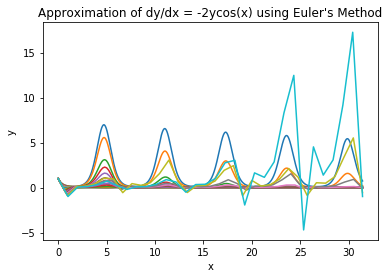

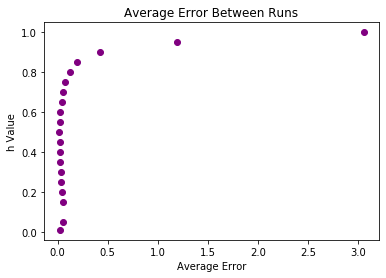

In [95]:
# Define parameters
hs = np.arange(.15,1.05,.05)
be=np.array([.01,.05])
hs=np.concatenate((be,hs))
avg=[]

x_start, x_end = 0, 10*np.pi
num_steps = []
avge=[]

# Function representing dy/dx = -2ycos(x)
def f(x, y):
    return -2 * y * np.cos(x)

for h in hs:
    error=[]
    avgy=0
    num_steps = int((x_end - x_start) / h)
    x_values=np.linspace(x_start, x_end, num_steps + 1)
    y_values=np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1


    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        error.append(abs(y_values[i+1]-y_values[i]))
    
        avgy+=y_values[i+1]
    avg.append(avgy/len(y_values))
    avge.append(np.mean(error))
   
    # Plot the results
    plt.plot(x_values, y_values, label=f"h = {h}")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2ycos(x) using Euler's Method")
#plt.legend()
plt.show()

plt.figure()
plt.plot(avge,hs,'o',color='purple')

plt.title('Average Error Between Runs')
plt.xlabel('Average Error')
plt.ylabel('h Value')
plt.show()

#print(f'Average values of y: {avg}')

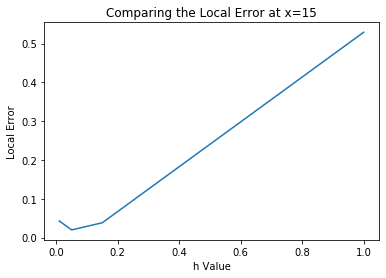

In [101]:
x=x_values[15]
y_true=np.exp(-2 * np.sin(x))
y=y_values[14]
lerr=[]

for h in hs:

    # Implement Euler's method
    y_euler= y + h * f(x, y)
    lerr.append(abs(y_true-y_euler))

# Plot the results
plt.plot(hs,lerr, label=f"h = {h}")
plt.xlabel('h Value')
plt.ylabel('Local Error')
plt.title("Comparing the Local Error at x=15")
#plt.legend()
plt.show()

### As the value of h increases there is an increase in the error between the points and their error to the exact solution. This is because increasing h values leads to higher peaks and lower troughs as seen in the first graph. This also decreases the number of steps, which means less values used to calculate the solution, meaning the calculated solution further deviates from the true solution. 

### Stability Analysis

### We can do a stability analysis. With f(x,y) = -2y we got the derivative to find our lambda value of -2. With f(x,y) = -2ycos(x), we have the added x component. The x component will be treated as a constant and we will differentiate in terms of y. This will give us a lambda value of -2cos(x). In order for the solution to be considered stable it needs to meet the condition |1+hλ| <= 1. In this case the stability condition would be |1-2cos(x)h| <= 1.